# AlphaFold — Comment prédire le repliement d'une protéine ?

---

## Le problème

Les médicaments fonctionnent en interagissant avec des protéines spécifiques —
en se logeant dans une poche à la surface de la protéine, comme une clé dans
une serrure. Pour concevoir cette clé, il faut connaître la forme exacte de
la serrure : la **structure 3D** de la protéine cible.

Une protéine est définie par sa séquence — une chaîne de lettres représentant
ses acides aminés (aussi appelés résidus). Par exemple, les 10 premiers résidus
de p53 :
```
M E E P Q S D P S V ...  (393 résidus au total)
```

Cette séquence se replie spontanément en une structure 3D complexe.
Le problème : **prédire cette structure 3D depuis la séquence seule**.

C'est un problème extraordinairement difficile. Pour une protéine de 100 résidus,
le nombre de conformations possibles est supérieur au nombre d'atomes dans
l'univers. Ce problème a résisté à 50 ans de recherche.

**AlphaFold l'a résolu.**

---

## Nos deux protéines

On travaille sur deux protéines choisies pour leur contraste structural :

| Protéine | UniProt | Longueur | Caractéristique |
|---|---|---|---|
| p53 | P04637 | 393 résidus | Partiellement désordonnée — cible majeure en oncologie |
| Lysozyme | P61626 | 148 résidus | Compacte et rigide — utilisée comme référence |

p53 est mutée dans plus de 50% des cancers humains. Restaurer sa fonction
est une stratégie thérapeutique majeure — mais concevoir un médicament
ciblant p53 nécessite de connaître précisément sa structure 3D.


## Section 1 — Le problème : de la séquence à la structure 3D

### Pourquoi le repliement est-il si difficile ?

Une protéine de 100 résidus peut théoriquement adopter un nombre de conformations
supérieur au nombre d'atomes dans l'univers observable. Pourtant, dans la cellule,
elle se replie en quelques microsecondes vers une structure unique et reproductible.

Ce paradoxe — appelé **paradoxe de Levinthal** — a fasciné les biologistes
pendant 50 ans. La structure adoptée n'est pas aléatoire : elle est entièrement
déterminée par la séquence. Mais la relation entre les deux est extrêmement
complexe à modéliser.

### Avant AlphaFold

Les méthodes expérimentales (cristallographie aux rayons X, cryo-EM) permettent
de déterminer la structure d'une protéine, mais elles sont :
- coûteuses : plusieurs années et centaines de milliers d'euros par structure
- limitées : certaines protéines résistent à la cristallisation
- lentes : incompatibles avec le criblage à grande échelle

En 2020, avant AlphaFold, seulement ~170 000 structures étaient connues
pour les ~200 millions de protéines répertoriées. La grande majorité des
protéines médicalement pertinentes n'avait pas de structure connue.

### Ce qu'AlphaFold change

AlphaFold 2 (Jumper et al., *Nature*, 2021) a résolu ce problème en le
reformulant comme une tâche d'apprentissage supervisé :

- **Entrée** : séquence d'acides aminés + alignements évolutifs (MSA)
- **Sortie** : coordonnées 3D de chaque atome + score de confiance par résidu

Entraîné sur toutes les structures connues, il atteint une précision comparable
à la cristallographie sur la majorité des protéines — en quelques secondes.

La base AlphaFold DB contient aujourd'hui des prédictions pour **plus de
200 millions de protéines**, dont l'intégralité du protéome humain.

In [1]:
import time
import warnings
warnings.filterwarnings("ignore")

import torch
import esm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import py3Dmol
from IPython.display import display
from sklearn.decomposition import PCA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {device}")
print(f"PyTorch : {torch.__version__}")
if device.type == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

def fetch_uniprot_sequence(uniprot_id):
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    lines = r.text.strip().split("\n")
    return "".join(lines[1:])

PROTEINS = {
    "p53": {
        "id": "P04637",
        "name": "Suppresseur de tumeur p53",
        "description": "Partiellement désordonnée — cible majeure en oncologie"
    },
    "lysozyme": {
        "id": "P61626",
        "name": "Lysozyme humain",
        "description": "Protéine globulaire compacte — structure rigide"
    },
}

print("\nRécupération des séquences depuis UniProt...\n")
for key, info in PROTEINS.items():
    info["sequence"] = fetch_uniprot_sequence(info["id"])
    seq = info["sequence"]
    print(f"{info['name']} ({info['id']})")
    print(f"  {len(seq)} résidus : {seq[:40]}...\n")

Device  : cuda
PyTorch : 2.11.0+cu130
GPU     : NVIDIA L4

Récupération des séquences depuis UniProt...

Suppresseur de tumeur p53 (P04637)
  393 résidus : MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAM...

Lysozyme humain (P61626)
  148 résidus : MKALIVLGLVLLSVTVQGKVFERCELARTLKRLGMDGYRG...




## Section 2 — L'entrée du modèle : encoder une séquence

### Comment transformer une séquence en quelque chose qu'un réseau comprend ?

Une séquence protéique c'est une chaîne de lettres — `MEEPQSDPSV...`.
Un réseau de neurones ne peut pas traiter des lettres directement.
Il faut les transformer en vecteurs numériques qui capturent le *sens*
de chaque résidu dans son contexte.

---

### Le parallèle avec le NLP

En traitement du langage naturel, des modèles comme BERT s'entraînent
sur une tâche similaire : on cache des mots dans une phrase et on demande
au modèle de les deviner.

> "Le chat est [MASK] sur le tapis" → deviner : **assis**

Pour réussir, le modèle doit comprendre le contexte — les mots autour
donnent des indices sur le mot manquant. Après entraînement, chaque mot
est représenté par un vecteur qui encode son sens *dans ce contexte précis*.

**ESM2 fait exactement la même chose, mais sur des protéines.**

> M E E _ Q S _ P S V ...  → deviner : **P** à la position 4, **D** à la position 7

La différence fondamentale : dans une phrase, le contexte c'est le sens
des mots. Dans une protéine, le contexte c'est la **pression évolutive**.

---

### Pourquoi l'évolution joue le rôle du "sens" ?

ESM2 est entraîné sur 250 millions de séquences de la même protéine
chez des milliers d'espèces différentes. Il observe des patterns comme :
```
Humain    : ... A (position 150) ... L (position 280) ...
Souris    : ... A (position 150) ... L (position 280) ...
Grenouille: ... V (position 150) ... M (position 280) ...
Requin    : ... A (position 150) ... L (position 280) ...
```

Le modèle remarque que **chaque fois que la position 150 change,
la position 280 change aussi** — toujours ensemble, jamais séparément.

Il ne sait pas pourquoi. Mais il apprend que ces deux positions sont liées.

La raison réelle : elles se touchent en 3D. Si l'une mute, l'autre
doit muter pour maintenir le contact physique — sinon la protéine
se déplie et l'organisme meurt. L'évolution a sélectionné ces
**mutations compensatoires** pendant des millions d'années.

ESM2 capte ce signal de co-évolution et l'encode dans ses représentations.
C'est pour ça que ses cartes d'attention ressemblent à des cartes de
contacts 3D — il a appris la géométrie depuis l'évolution, pas depuis
la physique.

---

### Ce que ça produit concrètement

Pour chaque résidu, ESM2 produit un vecteur de **1280 nombres** qui encode
tout ce contexte évolutif. Deux résidus identiques (deux leucines par exemple)
auront des vecteurs très différents s'ils jouent des rôles différents dans
la protéine — exactement comme le mot "banque" a des représentations
différentes dans un contexte financier ou géographique.

**C'est ce module qu'AlphaFold utilise en première étape** pour transformer
la séquence brute en représentations exploitables par son module de repliement.

In [2]:
# Chargement d'ESM2
print("Chargement d'ESM2...")
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
model = model.eval().to(device)
batch_converter = alphabet.get_batch_converter()
print("ESM2 chargé.\n")

def run_esm2(sequence, label="protein"):
    """
    Passe une séquence dans ESM2.
    Retourne :
      - embeddings (L, 1280) : vecteur par résidu, couche 33
      - attentions (33, 20, L, L) : poids d'attention par couche et par tête
      - contacts (L, L) : carte de contacts prédite
    """
    _, _, tokens = batch_converter([(label, sequence)])
    tokens = tokens.to(device)

    with torch.no_grad():
        out = model(
            tokens,
            repr_layers=[33],
            need_head_weights=True,
            return_contacts=True
        )

    L = len(sequence)
    embeddings = out["representations"][33][0, 1:-1, :].cpu().numpy()
    attentions = out["attentions"][0, :, :, 1:-1, 1:-1].cpu().numpy()
    contacts   = out["contacts"][0].cpu().numpy()

    return {"embeddings": embeddings, "attentions": attentions, "contacts": contacts}

print("Extraction des représentations ESM2...\n")
esm_results = {}
for key, info in PROTEINS.items():
    t0 = time.time()
    esm_results[key] = run_esm2(info["sequence"], label=key)
    elapsed = time.time() - t0
    emb = esm_results[key]["embeddings"]
    print(f"{info['name']} ({info['id']})")
    print(f"  → {emb.shape[0]} résidus × {emb.shape[1]} dimensions  ({elapsed:.1f}s)\n")

Chargement d'ESM2...


KeyboardInterrupt: 

## Section 3 — Visualiser ce qu'ESM2 a appris : les contacts entre résidus

### De la théorie à l'observation

Dans la section précédente, on a vu qu'ESM2 apprend à connecter des
résidus qui co-évoluent — c'est-à-dire des résidus proches en 3D.

On peut maintenant *vérifier* cela directement en extrayant les poids
d'attention du modèle entraîné et en les visualisant comme une matrice.

Chaque case (i, j) de cette matrice indique à quel point le résidu i
prête attention au résidu j. Si ESM2 a bien appris les contacts
structuraux, cette carte devrait ressembler à une carte de contacts 3D.

On visualise deux choses :
- La **carte d'attention brute** : ce que le modèle regarde
- La **carte de contacts prédite** : version raffinée qui agrège
  toutes les têtes d'attention pour prédire directement les contacts 3D

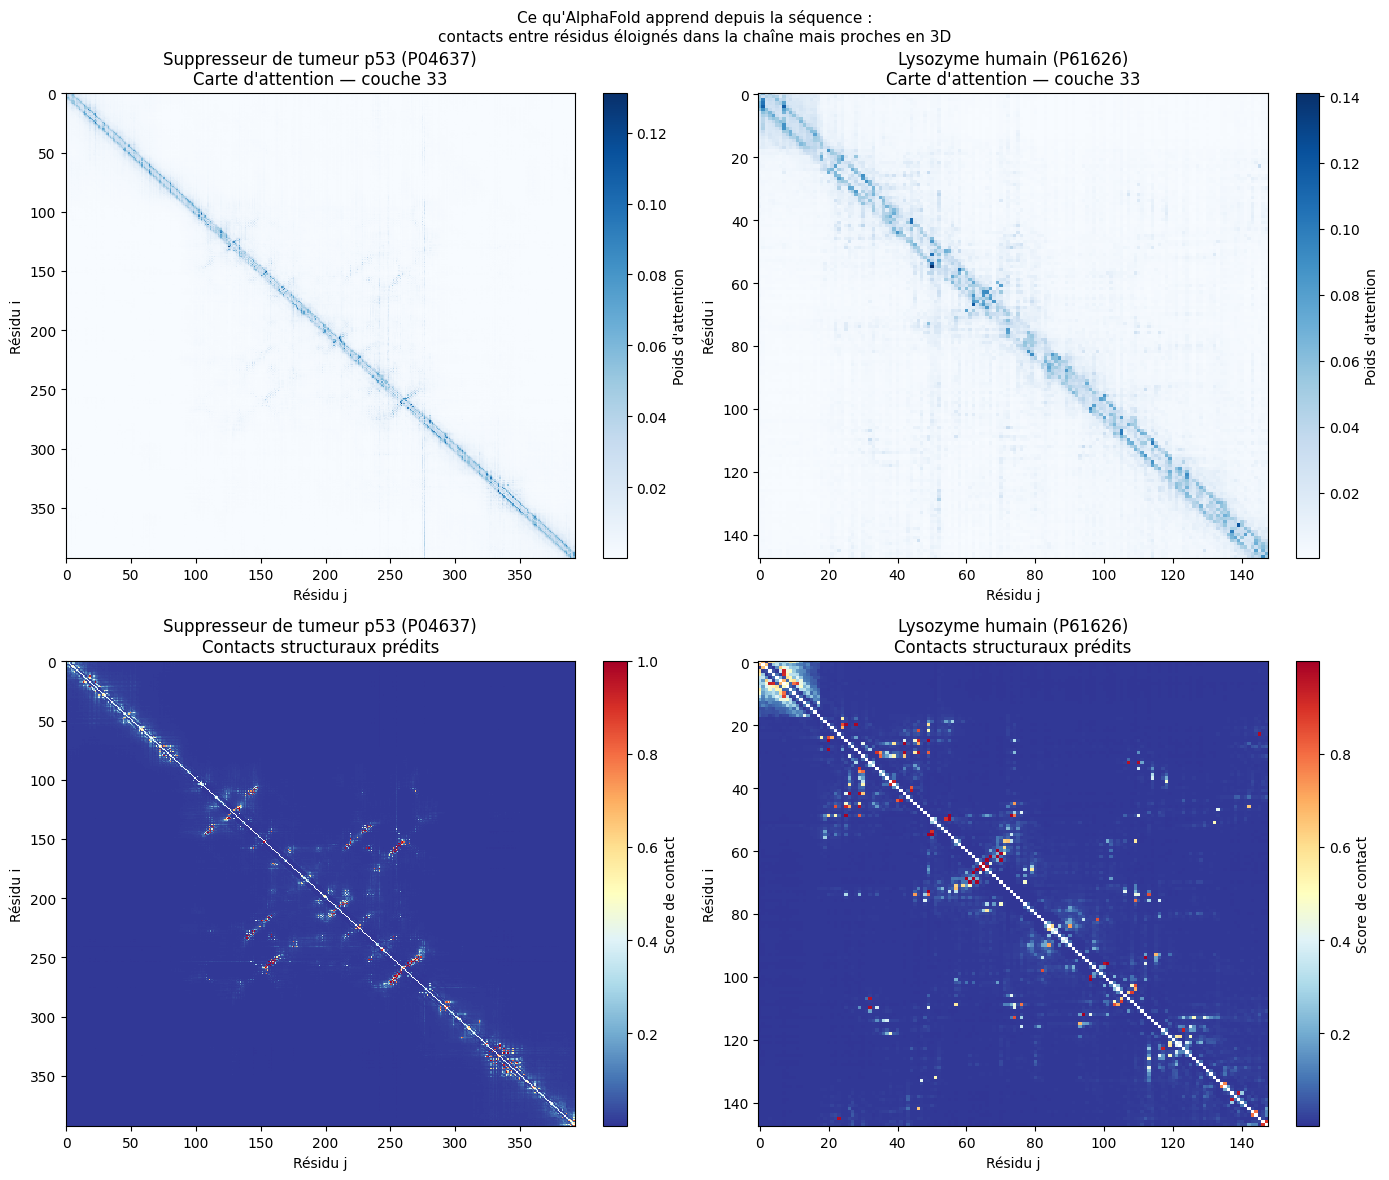

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for col, (key, info) in enumerate(PROTEINS.items()):
    attn = esm_results[key]["attentions"]  # (33, 20, L, L)
    cont = esm_results[key]["contacts"]    # (L, L)

    # Attention moyenne — dernière couche, toutes têtes
    attn_last_mean = attn[-1].mean(axis=0)  # (L, L)

    # ── Carte d'attention ──
    ax = axes[0][col]
    im = ax.imshow(attn_last_mean, cmap="Blues", aspect="auto",
                   interpolation="nearest")
    plt.colorbar(im, ax=ax, fraction=0.046, label="Poids d'attention")
    ax.set_xlabel("Résidu j")
    ax.set_ylabel("Résidu i")
    ax.set_title(f"{info['name']} ({info['id']})\n"
                 f"Carte d'attention — couche 33")

    # ── Carte de contacts ──
    ax = axes[1][col]
    cont_plot = cont.copy()
    np.fill_diagonal(cont_plot, np.nan)
    im2 = ax.imshow(cont_plot, cmap="RdYlBu_r", aspect="auto",
                    interpolation="nearest")
    plt.colorbar(im2, ax=ax, fraction=0.046, label="Score de contact")
    ax.set_xlabel("Résidu j")
    ax.set_ylabel("Résidu i")
    ax.set_title(f"{info['name']} ({info['id']})\n"
                 f"Contacts structuraux prédits")

plt.suptitle(
    "Ce qu'AlphaFold apprend depuis la séquence :\n"
    "contacts entre résidus éloignés dans la chaîne mais proches en 3D",
    fontsize=11
)
plt.tight_layout()
plt.savefig("contacts.png", dpi=150)
plt.show()

### Interprétation

**Lire ces cartes**

Chaque point (i, j) représente la relation entre le résidu i et le résidu j.
La diagonale (i = j) c'est chaque résidu avec lui-même — toujours fort.
Ce qui est intéressant c'est ce qui se passe **hors diagonale** : des résidus
éloignés dans la séquence mais que le modèle connecte fortement.

**Cartes d'attention (ligne du haut)**

Les deux protéines montrent une diagonale dominante — le modèle attribue
naturellement plus d'attention aux résidus voisins dans la séquence.

Le lysozyme montre des structures hors-diagonale plus marquées que p53 :
des blocs et des bandes qui indiquent que le modèle connecte des résidus
distants. C'est le signe d'une protéine avec une organisation spatiale
complexe.

**Cartes de contacts (ligne du bas)**

C'est ici que le contraste est frappant.

- **Lysozyme** : de nombreux points rouges hors-diagonale — des contacts
  à longue portée bien définis. Ce sont des résidus éloignés en séquence
  mais proches en 3D. C'est la signature d'une protéine compacte et repliée.
  Le modèle les a détectés depuis la séquence seule.

- **p53** : carte quasi vide hors diagonale. Les contacts à longue portée
  sont rares — ce qui reflète le désordre structural du domaine N-terminal.
  Une région qui n'a pas de forme 3D stable n'a pas de contacts persistants
  à apprendre.

**Ce que ça dit sur AlphaFold**

AlphaFold exploite exactement cette information pour prédire la structure 3D.
Une carte de contacts riche → structure stable → prédiction confiante → pLDDT élevé.
Une carte pauvre → région désordonnée → incertitude → pLDDT faible.

C'est ce qu'on va vérifier dans la section suivante.


## Section 3b — L'Evoformer : le cœur architectural d'AlphaFold

### Le problème du raffinage

Dans la Section 3, on a vu qu'ESM2 produit des représentations initiales
des résidus et détecte des contacts à longue portée. Mais ces représentations
sont encore imparfaites — elles ne tiennent pas compte de toutes les
interactions simultanées entre résidus.

Le défi est le suivant : pour affiner la représentation du résidu i,
il faut connaître ses contacts avec j et k. Mais pour affiner j, il faut
connaître ses contacts avec i et k. Et pour affiner k, il faut connaître
ses contacts avec i et j. Tout est interdépendant.

C'est le problème que l'**Evoformer** résout.

---

### Architecture de l'Evoformer

L'Evoformer est un bloc transformer empilé 48 fois dans AlphaFold 2.
Il maintient simultanément deux représentations :

- **La représentation de résidus** (MSA representation) : un vecteur
  par résidu, qui encode ses propriétés dans le contexte de la séquence
- **La représentation de paires** (pair representation) : un vecteur
  pour chaque paire (i, j), qui encode la relation entre les résidus i et j

La clé de l'Evoformer est que ces deux représentations **se mettent à jour
mutuellement** à chaque couche :

> La représentation de paires est mise à jour depuis les résidus :
> "ces deux résidus ont telles propriétés → leur relation probable est..."
>
> La représentation de résidus est mise à jour depuis les paires :
> "ce résidu est en contact avec ces voisins → ses propriétés se raffinent..."

Ce cycle de mises à jour mutuelles sur 48 couches permet au modèle de
construire progressivement une représentation cohérente de toute la
géométrie de la protéine.

---

### L'attention biaisée par les paires

Le mécanisme d'attention dans l'Evoformer n'est pas standard. Pour
calculer l'attention entre le résidu i et le résidu j, le modèle
**biaise le score d'attention par la représentation de la paire (i,j)** :

$$a_{ij} = \text{softmax}\left(\frac{q_i \cdot k_j}{\sqrt{d}} + b_{ij}\right)$$

où $b_{ij}$ est un biais appris depuis la représentation de paire.

Concrètement : si le modèle a appris que les résidus i et j sont
probablement en contact (représentation de paire forte), il va
augmenter leur score d'attention — ce qui va à son tour raffiner
leurs représentations individuelles.

---

### Pourquoi c'est une innovation ML importante

Les transformers standards traitent les éléments d'une séquence
indépendamment les uns des autres dans leur mécanisme d'attention.
L'Evoformer introduit une **dépendance structurée** : l'attention
entre deux résidus dépend explicitement de leur relation géométrique
estimée.

C'est ce couplage entre représentations de résidus et de paires qui
permet à AlphaFold de capturer des contraintes géométriques complexes
que les transformers standards ne peuvent pas représenter.

À l'issue des 48 couches de l'Evoformer, les représentations de paires
encodent une carte de contacts très précise — que le Structure Module
utilise ensuite pour produire les coordonnées 3D.


## Section 4 — La sortie d'AlphaFold : structure 3D et confiance

### Du contact à la structure

Dans la section précédente, on a vu qu'AlphaFold apprend quels résidus
sont proches en 3D depuis la séquence seule. Mais comment passer d'une
liste de contacts à des coordonnées 3D ?

Le problème est géométrique. Imagine qu'on sait que :
- Le résidu 50 et le résidu 300 sont proches
- Le résidu 100 et le résidu 250 sont proches
- Le résidu 75 et le résidu 180 sont proches

Ces contraintes **réduisent l'espace des structures possibles** — mais
elles ne définissent pas une solution unique. Pour un ensemble de
contraintes donné, il existe en général plusieurs structures 3D
compatibles. AlphaFold choisit la structure la plus probable parmi
celles qui respectent ces contraintes, en s'appuyant sur ce qu'il a
appris des ~170 000 structures connues pendant l'entraînement.

Ce passage se fait via le **Structure Module** : il part d'une position
aléatoire pour chaque résidu, puis itère :

> 1. Il regarde les contacts prédits → "le résidu 50 devrait être proche du 300"
> 2. Il ajuste les positions pour respecter cette contrainte
> 3. Il vérifie que la chaîne reste physiquement valide (longueurs de liaisons, angles fixes)
> 4. Il recommence jusqu'à convergence vers la structure la plus probable

À la fin, chaque résidu a des coordonnées x, y, z dans l'espace.

---

### Le pLDDT : définition rigoureuse

Le pLDDT est un score **par résidu** — AlphaFold produit une valeur
pour chaque lettre de la séquence. Pour p53 (393 résidus), on obtient
393 scores distincts, d'où le profil qu'on visualise.

#### Pourquoi plusieurs solutions impliquent de l'incertitude ?

On peut visualiser le problème comme un paysage énergétique :

- **Région ordonnée** : paysage avec un seul creux profond → une seule
  conformation stable → AlphaFold converge vers la même structure
  → **pLDDT élevé**
- **Région désordonnée** : paysage plat avec de nombreux creux peu
  profonds → plusieurs conformations également plausibles → AlphaFold
  ne peut pas choisir avec confiance → **pLDDT faible**

#### Définition mathématique

Le pLDDT est la version *prédite* du score lDDT (Local Distance
Difference Test, Mariani et al., 2013). Pour un résidu i :

$$\text{lDDT}(i) = \frac{1}{4} \sum_{t \in \{0.5, 1, 2, 4\} \text{Å}} \frac{1}{|N_i|} \sum_{j \in N_i} \mathbb{1}\left[|d_{ij}^{\text{pred}} - d_{ij}^{\text{ref}}| < t\right]$$

où :
- $N_i$ = résidus j à moins de 15 Å du résidu i dans la structure de référence
- $d_{ij}^{\text{pred}}$ = distance prédite entre résidu i et j
- $d_{ij}^{\text{ref}}$ = distance réelle entre résidu i et j
- $t$ = seuil de tolérance testé à 4 valeurs : 0.5, 1, 2, 4 Å

En pratique : pour chaque résidu i, on regarde tous ses voisins proches.
Pour chaque paire (i, j), on vérifie si la distance prédite est proche
de la distance réelle. Le score est la fraction de paires qui passent
ce test, moyennée sur les 4 seuils.

**Le p de pLDDT** signifie *predicted* : pendant l'inférence, AlphaFold
ne connaît pas la vraie structure. Il estime ce score via une tête de
réseau entraînée à prédire combien ses propres distances seraient
correctes — c'est une forme d'**incertitude calibrée**.

| pLDDT | Interprétation |
|---|---|
| > 90 | Très haute confiance — structure fiable |
| 70–90 | Bonne confiance |
| 50–70 | Basse confiance — à interpréter avec précaution |
| < 50 | Très basse confiance — région probablement désordonnée |

Un pLDDT faible ne signifie pas qu'AlphaFold a mal prédit — il signifie
que la région **n'a pas de forme 3D stable**. C'est une information
biologique en soi, exploitée directement en Section 5.

On récupère les structures pré-calculées par DeepMind depuis la base
**AlphaFold DB** pour nos deux protéines.

In [ ]:
def fetch_alphafold_structure(uniprot_id):
    """Récupère la structure PDB depuis l'API AlphaFold DB."""
    url = f"https://alphafold.ebi.ac.uk/api/prediction/{uniprot_id}"
    meta = requests.get(url, timeout=30).json()[0]
    pdb_string = requests.get(meta["pdbUrl"], timeout=60).text
    return {"pdb_string": pdb_string, "meta": meta}

def parse_plddt(pdb_string):
    """Extrait les scores pLDDT depuis la colonne B-factor du fichier PDB."""
    rows, seen = [], set()
    for line in pdb_string.splitlines():
        if not line.startswith("ATOM") or line[12:16].strip() != "CA":
            continue
        res_num = int(line[22:26].strip())
        if res_num in seen:
            continue
        seen.add(res_num)
        rows.append({
            "residue_index":  len(rows) + 1,
            "residue_number": res_num,
            "residue_name":   line[17:20].strip(),
            "plddt_score":    float(line[60:66].strip()),
        })
    return pd.DataFrame(rows)

print("Récupération des structures AlphaFold DB...\n")
af_results = {}
for key, info in PROTEINS.items():
    af_results[key] = fetch_alphafold_structure(info["id"])
    af_results[key]["plddt_df"] = parse_plddt(af_results[key]["pdb_string"])
    df = af_results[key]["plddt_df"]
    print(f"{info['name']} ({info['id']})")
    print(f"  pLDDT moyen : {df['plddt_score'].mean():.1f}")
    print(f"  > 90        : {(df['plddt_score'] > 90).mean()*100:.0f}%")
    print(f"  < 50        : {(df['plddt_score'] < 50).mean()*100:.0f}%\n")

Récupération des structures AlphaFold DB...

Suppresseur de tumeur p53 (P04637)
  pLDDT moyen : 75.1
  > 90        : 52%
  < 50        : 30%

Lysozyme humain (P61626)
  pLDDT moyen : 94.1
  > 90        : 88%
  < 50        : 1%




### 4a — Profils pLDDT

On visualise le score de confiance résidu par résidu, du N-terminal (gauche)
au C-terminal (droite). C'est la traduction directe de l'incertitude
d'AlphaFold le long de la chaîne.

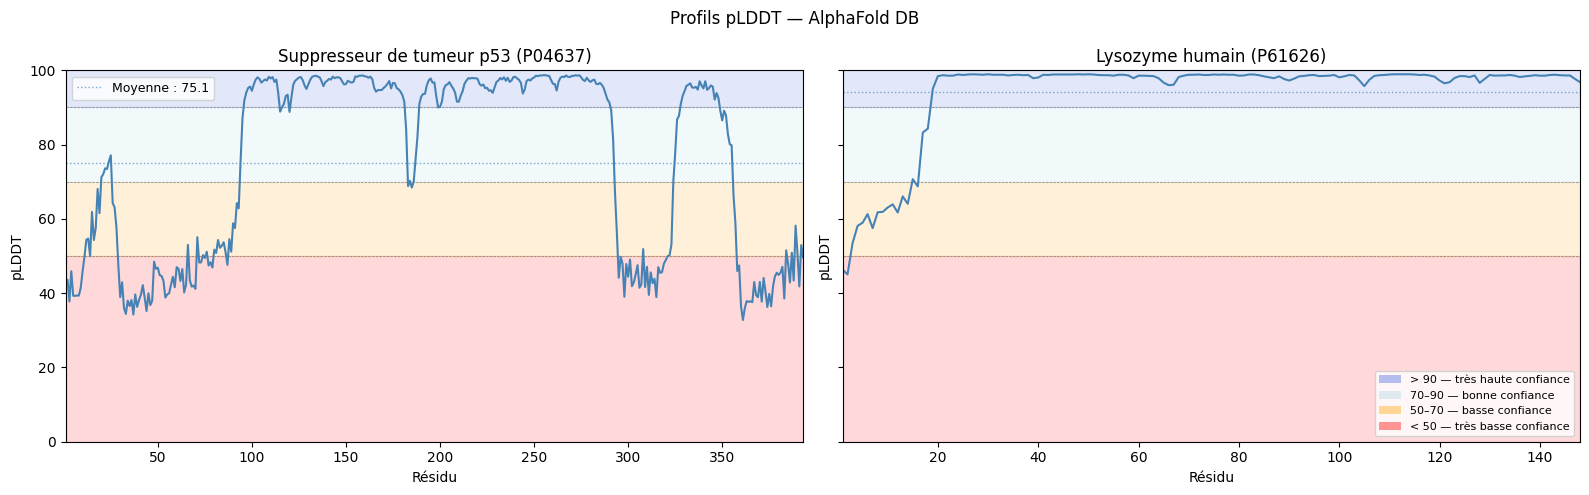

In [ ]:
from matplotlib.patches import Patch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, (key, info) in zip((ax1, ax2), PROTEINS.items()):
    df = af_results[key]["plddt_df"]

    ax.axhspan(0,   50, alpha=0.15, color="red",       zorder=0)
    ax.axhspan(50,  70, alpha=0.15, color="orange",    zorder=0)
    ax.axhspan(70,  90, alpha=0.15, color="lightblue", zorder=0)
    ax.axhspan(90, 100, alpha=0.15, color="royalblue", zorder=0)
    for thresh in (50, 70, 90):
        ax.axhline(thresh, color="grey", lw=0.5, ls="--", zorder=1)

    ax.plot(df["residue_index"], df["plddt_score"],
            color="steelblue", lw=1.5, zorder=2)

    mean_val = df["plddt_score"].mean()
    ax.axhline(mean_val, color="steelblue", lw=1, ls=":",
               alpha=0.7, label=f"Moyenne : {mean_val:.1f}")

    ax.set_xlim(1, len(df))
    ax.set_ylim(0, 100)
    ax.set_xlabel("Résidu")
    ax.set_ylabel("pLDDT")
    ax.set_title(f"{info['name']} ({info['id']})")
    ax.legend(fontsize=9)

legend_elements = [
    Patch(facecolor="royalblue", alpha=0.4, label="> 90 — très haute confiance"),
    Patch(facecolor="lightblue", alpha=0.4, label="70–90 — bonne confiance"),
    Patch(facecolor="orange",    alpha=0.4, label="50–70 — basse confiance"),
    Patch(facecolor="red",       alpha=0.4, label="< 50 — très basse confiance"),
]
ax2.legend(handles=legend_elements, loc="lower right", fontsize=8)

plt.suptitle("Profils pLDDT — AlphaFold DB", fontsize=12)
plt.tight_layout()
plt.savefig("plddt_profiles.png", dpi=150)
plt.show()

### Interprétation

Le lysozyme présente un profil quasi uniforme au-dessus de 90 dès le résidu 20,
ce qui reflète la rigidité d'une protéine globulaire compacte. Le creux initial
(résidus 1–18) correspond au peptide signal — un segment clivé absent dans la
protéine fonctionnelle mature.

Le profil de p53 est structurellement plus informatif. On rappelle que la chaîne
protéique s'étend du **N-terminal** (premier résidu, à gauche) au **C-terminal**
(dernier résidu, à droite). Trois régions se distinguent clairement : le domaine
N-terminal (résidus 1–100) présente un pLDDT inférieur à 50, caractéristique
d'une région intrinsèquement désordonnée sans conformation stable en solution.
Le domaine central de liaison à l'ADN (résidus 100–290) maintient un pLDDT
supérieur à 90 — c'est la région structurellement fiable et druggable de p53,
ciblée par des thérapies comme l'APR-246. Enfin, le domaine C-terminal
(résidus 330–393) présente à nouveau une chute de confiance, cohérente avec
son caractère régulateur et flexible.

Ce profil est directement cohérent avec les cartes de contacts de la Section 3 :
les régions à pLDDT élevé correspondent aux zones où les contacts à longue portée
étaient les plus denses. AlphaFold est confiant là où la séquence contraint
suffisamment la structure pour converger vers une conformation unique.


### 4b — Visualisation 3D

La structure 3D prédite par AlphaFold est colorée par score pLDDT —
bleu pour les régions de haute confiance, rouge pour les régions de
basse confiance. Cette représentation traduit le profil 1D de la section
précédente en espace tridimensionnel, et permet d'identifier visuellement
les régions structuralement fiables des régions désordonnées.

In [ ]:
for key, info in PROTEINS.items():
    print(f"{'─'*50}")
    print(f"{info['name']} ({info['id']})")
    print("Bleu = pLDDT élevé (fiable) | Rouge = pLDDT faible (désordonné)")
    print("Clic-gauche pour tourner | Scroll pour zoomer\n")

    view = py3Dmol.view(width=720, height=480)
    view.addModel(af_results[key]["pdb_string"], "pdb")
    view.setStyle({}, {"cartoon": {
        "colorscheme": {
            "prop": "b",
            "gradient": "rwb",
            "min": 50,
            "max": 90
        }
    }})
    view.zoomTo()
    view.show()
    print()

──────────────────────────────────────────────────
Suppresseur de tumeur p53 (P04637)
Bleu = pLDDT élevé (fiable) | Rouge = pLDDT faible (désordonné)
Clic-gauche pour tourner | Scroll pour zoomer



3Dmol.js failed to load for some reason. Please check your browser console for error messages.

None


──────────────────────────────────────────────────
Lysozyme humain (P61626)
Bleu = pLDDT élevé (fiable) | Rouge = pLDDT faible (désordonné)
Clic-gauche pour tourner | Scroll pour zoomer



3Dmol.js failed to load for some reason. Please check your browser console for error messages.

None

### Interprétation

La structure de p53 illustre parfaitement ce que le pLDDT mesure. Le cœur
bleu compact correspond au domaine de liaison à l'ADN (résidus ~100–290) —
une structure rigide et bien définie, accessible à la conception rationnelle
de médicaments. Les filaments rouges qui s'étendent dans toutes les directions
sont les régions désordonnées : sans conformation fixe, AlphaFold leur attribue
une position arbitraire dans l'espace, d'où ces formes étendues et irrégulières.

Le lysozyme présente à l'inverse une structure quasi entièrement bleue. Le
filament rouge à l'extrémité N-terminale correspond au peptide signal
(résidus 1–18), absent dans la protéine fonctionnelle mature.

Ces deux structures confirment visuellement ce que les cartes de contacts et
les profils pLDDT avaient établi quantitativement : AlphaFold est confiant
là où les contacts structuraux contraignent suffisamment la géométrie locale,
et incertain là où ils sont absents.


## Section 5 — Implication pour le drug discovery

### De la structure à la stratégie thérapeutique

À ce stade, on dispose d'une caractérisation complète de nos deux protéines.
La question thérapeutique est maintenant concrète : que fait-on de ces résultats ?

---

### Le lysozyme : le cas favorable

Le lysozyme présente un pLDDT supérieur à 90 sur presque toute sa longueur.
Sa structure est fiable et stable — on peut l'utiliser telle quelle pour
identifier des poches de liaison à sa surface et concevoir des molécules
complémentaires. C'est la situation idéale en drug design rationnel :
une structure de confiance, des cibles géométriques bien définies.

---

### p53 : le cas difficile

p53 est un exemple représentatif des défis réels du drug discovery.
Avec 30% de résidus à pLDDT inférieur à 50, on ne peut pas appliquer
une stratégie uniforme. La réponse dépend du domaine considéré.

**Domaine de liaison à l'ADN (résidus 100–290, pLDDT > 90)**

C'est la seule région où un ciblage direct est possible. La structure
est stable et bien définie — AlphaFold la prédit avec haute confiance,
ce qui permet d'identifier des poches de liaison accessibles. C'est
sur ce domaine qu'agit l'APR-246, une molécule en essai clinique qui
se lie au domaine de liaison à l'ADN et restaure la fonction de p53
mutée dans certains cancers.

**Domaine N-terminal (résidus 1–100, pLDDT < 50)**

Ce domaine est intrinsèquement désordonné — il n'a pas de forme fixe
en solution. Le cibler directement est donc impossible : il n'y a pas
de poche de liaison stable à exploiter.

La stratégie consiste à cibler ses **partenaires de liaison**. En
conditions normales, ce domaine désordonné se lie à une protéine
appelée MDM2, qui inhibe p53 et déclenche sa dégradation. MDM2,
elle, est bien structurée. Des molécules comme le Nutlin-3 bloquent
l'interaction MDM2–p53 en se logeant dans la poche de liaison de MDM2
— restaurant ainsi l'activité de p53 sans jamais toucher son domaine
désordonné.

**Domaine C-terminal (résidus 330–393, pLDDT < 50)**

Ce domaine régulateur flexible est également difficile à cibler
directement. Les stratégies envisagées passent par des modifications
post-traductionnelles ou des peptides stabilisateurs qui lui imposent
une conformation définie.

---

### Ce qu'AlphaFold change concrètement

Avant AlphaFold, caractériser ces quatre domaines nécessitait des années
de cristallographie et de RMN — et certaines régions désordonnées
résistaient à toute caractérisation expérimentale.

AlphaFold produit cette carte en quelques secondes depuis la séquence seule.
Pour un chercheur, cela signifie pouvoir orienter sa stratégie thérapeutique
dès le début du projet — avant d'avoir réalisé une seule expérience.

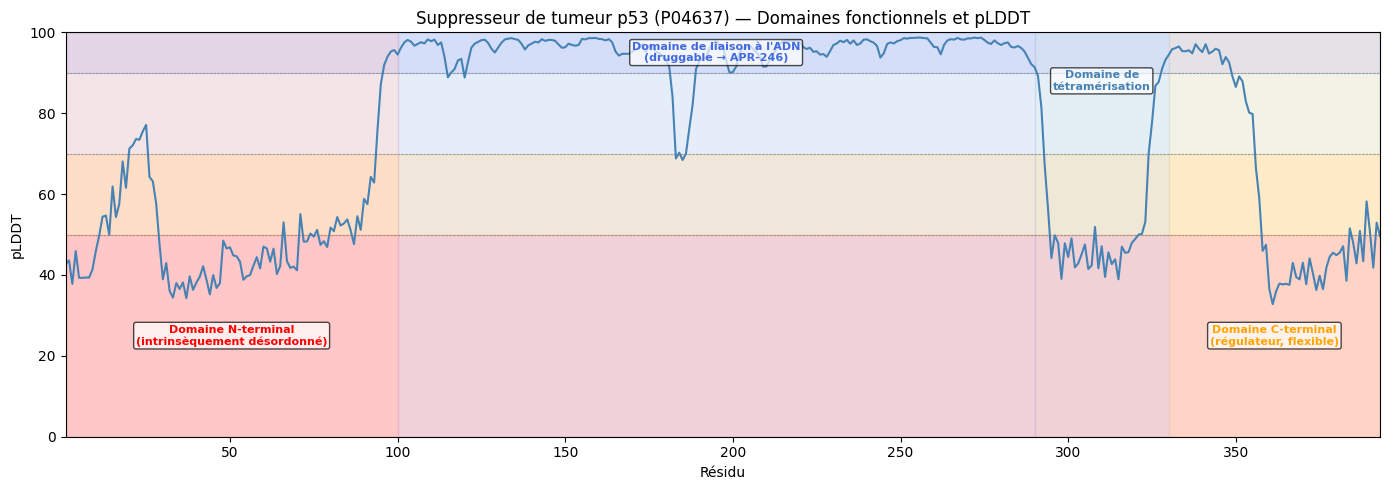

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

df = af_results["p53"]["plddt_df"]

# Bandes de confiance
ax.axhspan(0,   50, alpha=0.15, color="red",       zorder=0)
ax.axhspan(50,  70, alpha=0.15, color="orange",    zorder=0)
ax.axhspan(70,  90, alpha=0.15, color="lightblue", zorder=0)
ax.axhspan(90, 100, alpha=0.15, color="royalblue", zorder=0)
for thresh in (50, 70, 90):
    ax.axhline(thresh, color="grey", lw=0.5, ls="--", zorder=1)

ax.plot(df["residue_index"], df["plddt_score"],
        color="steelblue", lw=1.5, zorder=2)

# Annotations des domaines
domains = [
    (1,   100, "Domaine N-terminal\n(intrinsèquement désordonné)",  25, "red"),
    (100, 290, "Domaine de liaison à l'ADN\n(druggable → APR-246)", 95, "royalblue"),
    (290, 330, "Domaine de\ntétramérisation",                        88, "steelblue"),
    (330, 393, "Domaine C-terminal\n(régulateur, flexible)",         25, "orange"),
]

for start, end, label, y_label, color in domains:
    ax.axvspan(start, end, alpha=0.08, color=color, zorder=0)
    ax.text((start + end) / 2, y_label, label,
            ha="center", va="center", fontsize=8,
            color=color, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))

ax.set_xlim(1, len(df))
ax.set_ylim(0, 100)
ax.set_xlabel("Résidu")
ax.set_ylabel("pLDDT")
ax.set_title("Suppresseur de tumeur p53 (P04637) — Domaines fonctionnels et pLDDT")

plt.tight_layout()
plt.savefig("p53_domains_plddt.png", dpi=150)
plt.show()

### Interprétation

Cette figure résume tout ce que ce notebook a construit.

Chaque domaine de p53 a un profil pLDDT distinct, et ce profil détermine
directement la stratégie thérapeutique applicable :

| Domaine | Résidus | pLDDT | Caractéristique | Stratégie thérapeutique |
|---|---|---|---|---|
| N-terminal | 1–100 | < 50 | Intrinsèquement désordonné | Cibler ses partenaires de liaison (MDM2) |
| Liaison à l'ADN | 100–290 | > 90 | Compact, druggable | Ciblage direct — APR-246, PRIMA-1 |
| Tétramérisation | 290–330 | ~50 | Semi-flexible | Peptides stabilisateurs |
| C-terminal | 330–393 | < 50 | Régulateur flexible | Modifications post-traductionnelles |

**Avant AlphaFold**, identifier ces domaines nécessitait des années de
cristallographie et de RMN. AlphaFold les prédit en quelques secondes,
depuis la séquence seule.

**Ce que le pLDDT change concrètement** : un chercheur qui reçoit cette
figure sait immédiatement où concentrer ses efforts de conception de
médicaments — sans avoir réalisé une seule expérience.


## Conclusion

### Ce que ce notebook a démontré

Ce notebook a suivi un fil directeur unique : comment AlphaFold prédit
le repliement d'une protéine, et ce que cela change concrètement pour
la conception de médicaments. On a décomposé le pipeline en quatre
étapes observables.

**Encodage de la séquence (Section 2)**

ESM2 transforme chaque résidu en un vecteur de 1280 dimensions en
exploitant les patterns de co-évolution présents dans 250 millions
de séquences. Deux résidus identiques ont des représentations
différentes selon leur contexte — exactement comme les embeddings
contextuels en NLP.

**Détection des contacts (Section 3)**

Le mécanisme d'attention capte quels résidus co-évoluent, c'est-à-dire
quels résidus sont proches en 3D. Les cartes de contacts illustrent
directement ce résultat : le lysozyme présente des contacts à longue
portée nombreux et bien définis, tandis que le domaine désordonné de
p53 en est quasi dépourvu.

**Raffinage par l'Evoformer (Section 3b)**

Sur 48 couches, l'Evoformer met à jour mutuellement les représentations
de résidus et de paires. Ce couplage permet de construire progressivement
une représentation géométrique cohérente de toute la protéine — une
innovation architecturale que les transformers standards ne permettent
pas.

**Structure 3D et confiance (Section 4)**

Le Structure Module traduit ces représentations en coordonnées atomiques.
Le pLDDT quantifie la confiance résidu par résidu : élevé là où les
contraintes géométriques convergent vers une conformation unique, faible
là où plusieurs conformations sont également plausibles.

---

### Ce que les résultats nous disent sur p53

L'analyse de p53 illustre la valeur opérationnelle d'AlphaFold en drug
discovery. La protéine n'est pas uniformément accessible : son domaine
de liaison à l'ADN (pLDDT > 90) constitue une cible structurale fiable,
tandis que ses domaines N- et C-terminaux désordonnés (pLDDT < 50)
nécessitent des stratégies indirectes — ciblage de partenaires de liaison
comme MDM2, ou stabilisation conformationnelle.

Cette carte de ciblage, qu'AlphaFold produit en quelques secondes depuis
la séquence seule, aurait nécessité des années de caractérisation
expérimentale avant son développement.

---

### Vers les Graph Neural Networks

AlphaFold répond à la question : *sur quelle région de la protéine agir ?*

La question suivante est : *avec quelle molécule ?* Évaluer si un candidat
médicament sera soluble, stable, non toxique et actif contre notre cible
nécessite de représenter les molécules de façon adaptée à leur structure
géométrique et chimique. C'est précisément ce que font les **Graph Neural
Networks** — en représentant les molécules comme des graphes d'atomes et
de liaisons chimiques.